# Preprocessing pipeline

**Goal** here is to select a proper window of samples.

Apply **filtering** within the window to interpolate data during blinks

Use common column names to be consistent across different sources of data

- 3D gaze coordinates on screen:
  ```text
    gaze_point_3d_x, gaze_point_3d_y, gaze_point_3d_z
  ```   
- 2D normalized gaze point on screen:
  ```text
    gaze_point_screen_x, gaze_point_screen_y
  ```   
- Pupil diameter (mm) & validity:
  ```text
    pupil diameter, confidence
  ```   


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import cognitive_models.preprocessing as cwpre
import cognitive_models.interpolate as cwi
from importlib import reload
reload(cwi)
reload(cwpre)
COLET_DATASET_DIR = Path(cwpre.__file__).parents[2] / "datasets" / "COLET_CSV"
PARTICIPANTS = [1]
EXPERIMENTS = [1,2,3,4]

In [2]:
# Load the dataset
eye_df = cwpre.load_colet_data(COLET_DATASET_DIR, PARTICIPANTS, EXPERIMENTS)

print("Loaded eye-tracking data shape:", eye_df.shape)

There are 0 non matching timestamp_sec within the limits
Final merged dataset has 4099 records at 120 Hz
Final merged and resampled dataset has 2028 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 3437 records at 120 Hz
Final merged and resampled dataset has 1709 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 8757 records at 120 Hz
Final merged and resampled dataset has 4285 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 4637 records at 120 Hz
Final merged and resampled dataset has 2290 records at 60 Hz
Loaded eye-tracking data shape: (10312, 11)


In [3]:
# Checking the different cl values for subject id
eye_df['cl_class'] = eye_df['mean_score'].apply(lambda x: 'low' if x < 29 else ('medium' if x < 50 else 'high'))
display(eye_df[eye_df["subject_id"] == 1].groupby("task_id")["cl_class"].unique())

task_id
1       [low]
2    [medium]
3      [high]
4    [medium]
Name: cl_class, dtype: object

In [4]:
eye_df.columns

Index(['timestamp_sec', 'pupil_diameter', 'confidence', 'gaze_point_screen_x',
       'gaze_point_screen_y', 'gaze_point_3d_x', 'gaze_point_3d_y',
       'gaze_point_3d_z', 'subject_id', 'task_id', 'mean_score', 'cl_class'],
      dtype='str')

## A. Extract window

Extract a proper window for analysis. Also validates invididual methods used for preprocessing.

*A priori* using $T\approx 10s$ consisting of $N=512$ samples seems like a good start.

Thus, inference could be done on a *per second* basis, giving overlapping windows of N~448 samples

In [5]:
N = 600 # Number of samples in the window
offset = 0*300 # Offset in # samples for the start of the window
fs = 60
SUBJECT_ID = 1
TASK_ID = 3

subject_df = eye_df[(eye_df["subject_id"] == SUBJECT_ID) & (eye_df["task_id"] == TASK_ID)].reset_index(drop=True)
print("Extracting a window of {} samples which corresponds to {:.2f} seconds".format(N, N/fs))
# window_df = subject_df.iloc[offset:offset+N].copy()
window_df = subject_df.copy()

window_df['confidence'].describe()

Extracting a window of 600 samples which corresponds to 10.00 seconds


count    4285.000000
mean        0.859129
std         0.232593
min         0.000000
25%         0.882289
50%         0.950991
75%         0.970220
max         0.991103
Name: confidence, dtype: float64

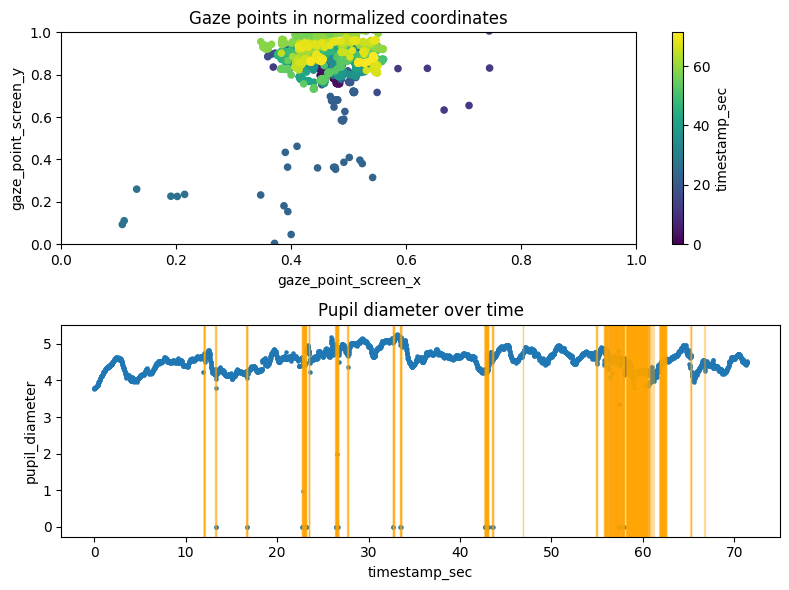

In [6]:
import matplotlib
# Visualize a bit the data in the window
fig = plt.figure(figsize=(8, 6), tight_layout=True)
ax0 = fig.add_subplot(2, 1, 1)
ax2 = fig.add_subplot(2, 1, 2)
# Plot gaze data in normalized coordinates
colormap = matplotlib.colormaps['viridis']
ax0.set_xlim(0, 1)
ax0.set_ylim(0, 1)
window_df.plot("gaze_point_screen_x", "gaze_point_screen_y", kind='scatter', c='timestamp_sec', colormap=colormap, title="Gaze points in normalized coordinates", ax=ax0)

# Plot (best of the 2 eyes) pupil diameter over time 
# Inverse colormap mapping
window_df.plot("timestamp_sec", "pupil_diameter", kind='scatter', title="Pupil diameter over time", ax=ax2, sizes=[5])

# Overlay the blinks as vertical zones
# blink_df['blink_timestamp'] = blink_df['start_timestamp'] - window_df['timestamp_sec'].min() # Align blink timestamps with window timestamps
# blink_df_window = blink_df[(blink_df['blink_timestamp'] >= window_df['timestamp_sec'].min()) & (blink_df['blink_timestamp'] <= window_df['timestamp_sec'].max())]
# if blink_df_window.empty:
#     print("No (official) blinks detected in the current window.")
# for _, row in blink_df_window.iterrows():
#     ax2.axvspan(row['timestamp'], row['timestamp'] + row['duration'], color='red', alpha=0.3)

# Show low confidence zones
window_df['low_confidence'] = window_df['confidence'] < 0.5
for _, row in window_df[window_df.low_confidence].iterrows():
    ax2.axvspan(row['timestamp_sec'], row['timestamp_sec'] + 1.0/240, color='orange', alpha=0.3)

Pipeline goes as follow:
1. Identify gaps and blinks
2. Remove low confidence samples
3. Apply margin to big gaps (> 75ms)
4. Filter pupil data
5. Calculate gaze angles
6. Interpolate gaps < 300ms by using resampling strategy (both pupil & gaze angle)

Detected gaps and blinks in the current window:


,start_id,stop_id,start_timestamp,stop_timestamp,duration_ms,is_blink
0,718,724,11.969048,12.069067,100.02,True
1,795,799,13.252638,13.319318,66.68,False
2,998,1005,16.636647,16.753338,116.69,True
3,1363,1391,22.721197,23.187957,466.76,False
4,1408,1412,23.471348,23.538027,66.68,False
5,1582,1602,26.371928,26.705327,333.40,False
6,1660,1665,27.672187,27.755537,83.35,False
7,1959,1967,32.656517,32.789878,133.36,True
8,2007,2015,33.456677,33.590038,133.36,True
9,2560,2585,42.675187,43.091938,416.75,False


Removed 468 low confidence samples from the window.
Detected pupil diameter outliers in the current window:


,timestamp_sec,pupil_diameter,dilation_speed,is_outlier
716,11.935707,4.582784,20.486295,True
717,11.952378,4.241277,20.486295,True
800,13.335987,3.788127,15.402667,True
801,13.352657,4.044889,15.402667,True
1101,18.353658,4.309991,14.768684,True
1102,18.370327,4.556184,14.768684,True
1413,23.554697,4.229695,14.370038,True
1414,23.571368,4.469244,14.370038,True
1551,25.855158,4.785231,13.727077,True
1552,25.871827,5.014062,13.727077,True


Removed 27 pupil diameter outliers from the window.
Removed 105 samples due to low confidence and proximity to detected blinks/gaps.


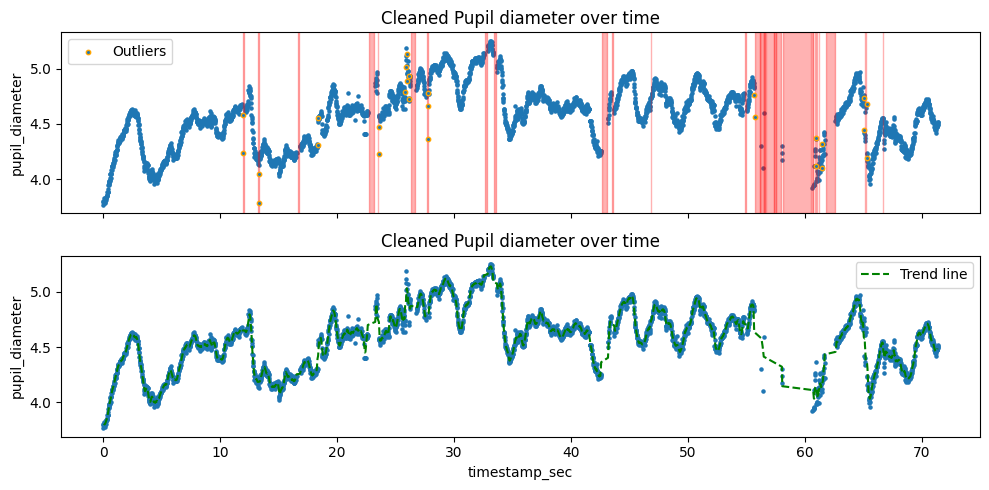

In [7]:
import cognitive_models.gaze_utils as cwgaze
import cognitive_models.pupil_utils as cwpupil
reload(cwgaze)
reload(cwpupil)

window_df_clean = window_df.copy()

CONFIDENCE_THRESHOLD = 0.5
MARGINS = 75 / 1000 # 50 ms margins around detected blinks and gaps
DURATION_THRESHOLD = 75
 
# Detect gaps and blinks in the current window
gaps_df = cwgaze.detect_gaps_and_blinks(window_df_clean, confidence_threshold=CONFIDENCE_THRESHOLD)
print("Detected gaps and blinks in the current window:")
display(gaps_df)

# Remove low confidence samples
n_to_remove = window_df_clean[window_df_clean["confidence"] < CONFIDENCE_THRESHOLD].shape[0]
window_df_clean = window_df_clean[window_df_clean["confidence"] >= CONFIDENCE_THRESHOLD]
print(f"Removed {n_to_remove} low confidence samples from the window.")

# Detect pupil diameter outliers
outliers_df = cwpupil.detect_outliers(window_df_clean, column="pupil_diameter", n_multiplier=15)
print("Detected pupil diameter outliers in the current window:")
display(outliers_df[["timestamp_sec", "pupil_diameter", "dilation_speed", "is_outlier"]])
window_df_clean = window_df_clean[~window_df_clean["timestamp_sec"].isin(outliers_df["timestamp_sec"])]
print(f"Removed {outliers_df.shape[0]} pupil diameter outliers from the window.")

# Remove samples that are within the margins of detected blinks and gaps
size_before = window_df_clean.shape[0]
for _, row in gaps_df[gaps_df['duration_ms'] >= DURATION_THRESHOLD].iterrows():
    idx_to_drop = window_df_clean[
        (window_df_clean['timestamp_sec'] >= row['start_timestamp'] - MARGINS) &
        (window_df_clean['timestamp_sec'] <= row['stop_timestamp'] + MARGINS)
    ].index
    window_df_clean.drop(idx_to_drop, inplace=True)

size_after = window_df_clean.shape[0]
print(f"Removed {size_before - size_after} samples due to low confidence and proximity to detected blinks/gaps.")

# Before interpolation, plot the pupil diameter with the detected gaps and blinks
fig, axs = plt.subplots(2, 1, figsize=(10, 5), tight_layout=True, sharex=True)
window_df_clean.plot("timestamp_sec", "pupil_diameter", kind='scatter', title="Cleaned Pupil diameter over time", ax=axs[0], sizes=[5])
for _, row in gaps_df.iterrows():
    axs[0].axvspan(row['start_timestamp'], row['stop_timestamp'], color='red', alpha=0.3)
outliers_df.plot("timestamp_sec", "pupil_diameter", kind='scatter', ax=axs[0], sizes=[10], label="Outliers", edgecolors='orange')
axs[0].legend()

# Plot pupil diameter without outliers
window_df_clean.plot("timestamp_sec", "pupil_diameter", kind='scatter', title="Cleaned Pupil diameter over time", ax=axs[1], sizes=[5])
# Show a trend line to see the overall trend of the pupil diameter (using window convolution)
trend_line = np.convolve(window_df_clean["pupil_diameter"], np.ones(10)/10, mode='valid')
axs[1].plot(window_df_clean["timestamp_sec"][5:-4], trend_line[:len(window_df_clean)], color='green', label="Trend line", linestyle='--')
axs[1].legend()

After interpolation, we have 258 interpolated samples and 3926 total samples.


<Axes: title={'center': 'Interpolated Gaze angle delta over time'}, xlabel='timestamp_sec', ylabel='gaze_angle_delta_deg'>

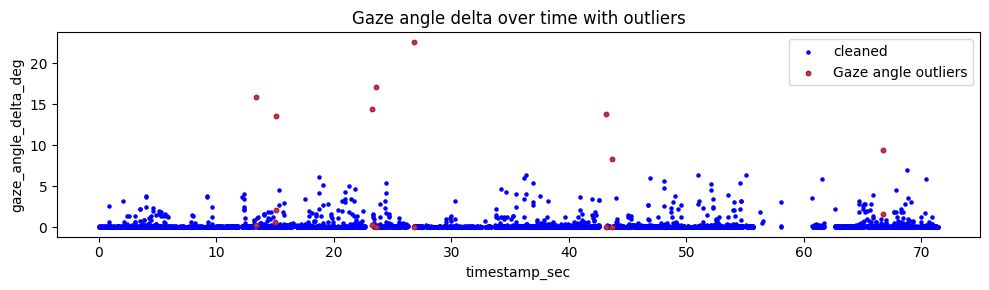

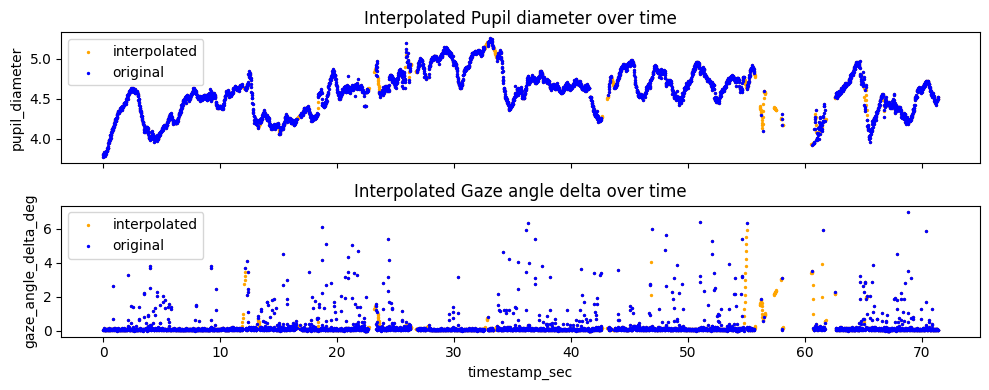

In [8]:
reload(cwi)
# Calculate gaze angles
window_df_clean['gaze_angle_delta_deg'] = cwgaze.calculate_gaze_angular_delta(window_df_clean, gaze_point_columns_prefix="gaze_point_3d")
outliers_df_gaze = cwpupil.detect_outliers(window_df_clean, column="gaze_angle_delta_deg", n_multiplier=200)
# drop gaze angle outliers from the clean dataframe
fig, ax = plt.subplots(figsize=(10, 3), tight_layout=True)
window_df_clean.plot("timestamp_sec", "gaze_angle_delta_deg", kind='scatter', title="Gaze angle delta over time with outliers", color='blue', sizes=[5], ax=ax, label="cleaned")
outliers_df_gaze.plot("timestamp_sec", "gaze_angle_delta_deg", kind='scatter', ax=ax, sizes=[10], label="Gaze angle outliers", edgecolors='red')
ax.legend()
ax.set_title("Gaze angle delta over time with outliers")
window_df_clean = window_df_clean[~window_df_clean["timestamp_sec"].isin(outliers_df_gaze["timestamp_sec"])]

# Only interpolate pupil diameter where gaps are smaller than a threshold
INTERPOLATION_THRESHOLD = 300 # ms
window_pupil_df_interpolated = cwi.interpolate_pupil_data(window_df_clean, gaps_df, column="pupil_diameter", max_gap=INTERPOLATION_THRESHOLD)
window_gaze_df_interpolated = cwi.interpolate_gaze(window_df_clean, gaps_df, columns=["gaze_angle_delta_deg", "gaze_point_screen_x", "gaze_point_screen_y"], max_gap=INTERPOLATION_THRESHOLD)
print(f"After interpolation, we have {window_pupil_df_interpolated['is_interpolated'].sum()} interpolated samples and {window_pupil_df_interpolated.shape[0]} total samples.")

fig, axs = plt.subplots(2,1, figsize=(10, 4), tight_layout=True, sharex=True)
window_pupil_df_interpolated.plot("timestamp_sec", "pupil_diameter", kind='scatter', title="Interpolated Pupil diameter over time", color='orange', sizes=[2], ax=axs[0], label="interpolated")
window_df_clean.plot("timestamp_sec", "pupil_diameter", kind='scatter', title="Interpolated Pupil diameter over time", color='blue', sizes=[2], ax=axs[0], label="original")
axs[0].legend()
window_gaze_df_interpolated.plot("timestamp_sec", "gaze_angle_delta_deg", kind='scatter', title="Interpolated Gaze angle delta over time", color='orange', sizes=[2], ax=axs[1], label="interpolated")
window_df_clean.plot("timestamp_sec", "gaze_angle_delta_deg", kind='scatter', title="Interpolated Gaze angle delta over time", color='blue', sizes=[2], ax=axs[1], label="original")

Found 177 transitions between saccades and fixations
Will mark 1 short fixations as saccades
Found 85 fixations and 84 saccades in the current window.


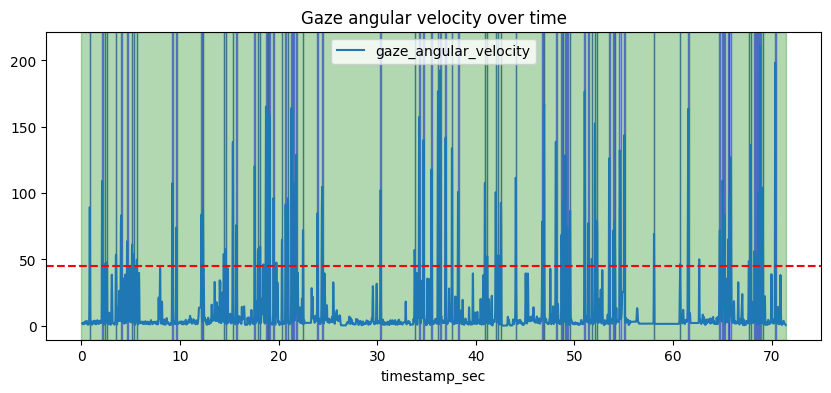

In [9]:
reload(cwgaze)
# Extract required features for the window
window_gaze_df_interpolated['gaze_angular_velocity'] = cwgaze.calculate_angular_velocity(window_gaze_df_interpolated)

window_df, fixations_df, saccades_df = cwgaze.calculate_fixations_saccades_ivt(window_gaze_df_interpolated, gaps_df, ivt_threshold=45)

# Plot fixations / saccades zones
fig, ax = plt.subplots(figsize=(10, 4))
window_df.plot("timestamp_sec", "gaze_angular_velocity", kind='line', title="Gaze angular velocity over time", ax=ax)
for _, row in fixations_df.iterrows():
    ax.axvspan(row['start_timestamp'], row['stop_timestamp'] + 1.0/fs, color='green', alpha=0.3)
for _, row in saccades_df.iterrows():
    ax.axvspan(row['start_timestamp'], row['stop_timestamp'] + 1.0/fs, color='blue', alpha=0.3)
ax.axhline(45, color='red', linestyle='--', label="IVT threshold")

print(f"Found {fixations_df.shape[0]} fixations and {saccades_df.shape[0]} saccades in the current window.")


Testing I-DT algorithm if gaze angular velocity not available

Detected 99 fixations and 98 saccades with IDT algorithm


Text(0.5, 1.0, 'I-VT detected fixations (green) and saccades (blue)')

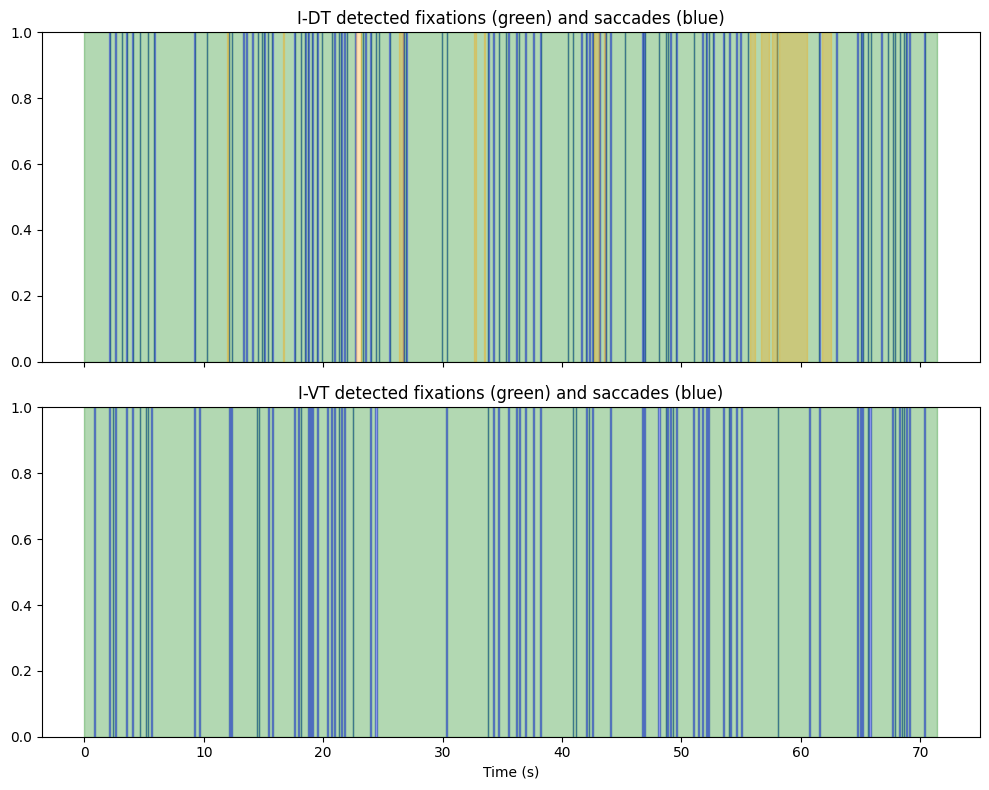

In [10]:
# I-DT algorithm for fixations / saccades
IDT_DURATION_THRESHOLD = 100 # ms
IDT_DISPERSION_THRESHOLD = 0.05 # normalized units

fixations_df_idt, saccades_df_idt = cwgaze.calculate_fixations_saccades_idt(window_gaze_df_interpolated, gaps_df, idt_duration_threshold=IDT_DURATION_THRESHOLD, idt_dispersion_threshold=IDT_DISPERSION_THRESHOLD)

# Plot I-DT fixations / saccades zones
fig, ax = plt.subplots(2,1, figsize=(10, 8), tight_layout=True, sharex=True)
for _, row in fixations_df_idt.iterrows():
    ax[0].axvspan(row['start_timestamp'], row['stop_timestamp'] + 1.0/fs, color='green', alpha=0.3)
for _, row in saccades_df_idt.iterrows():
    ax[0].axvspan(row['start_timestamp'], row['stop_timestamp'] + 1.0/fs, color='blue', alpha=0.3)
ax[0].set_title("I-DT detected fixations (green) and saccades (blue)")
for _, row in gaps_df[gaps_df['duration_ms'] > IDT_DURATION_THRESHOLD].iterrows():
    ax[0].axvspan(row['start_timestamp'], row['stop_timestamp'], color='orange', alpha=0.3)
for _, row in fixations_df.iterrows():
    ax[1].axvspan(row['start_timestamp'], row['stop_timestamp'] + 1.0/fs, color='green', alpha=0.3)
for _, row in saccades_df.iterrows():
    ax[1].axvspan(row['start_timestamp'], row['stop_timestamp'] + 1.0/fs, color='blue', alpha=0.3)
ax[1].set_xlabel("Time (s)")
ax[1].set_title("I-VT detected fixations (green) and saccades (blue)")

In [151]:
# Using the preprocessing function
import cognitive_models.preprocessing as cwpre
import cognitive_models.features as cwfeat
reload(cwpupil)
reload(cwgaze)
reload(cwpre)
reload(cwfeat)

# First step is to preprocess the data per subject per task
processed_df, gaze_df, pupil_df, gaps_df = cwpre.preprocess_colet_data(subject_df, verbose=True)
if processed_df['low_confidence_percentage'].iloc[0] > 30:
    t_start = processed_df['timestamp_sec'].min()
    t_end = processed_df['timestamp_sec'].max()
    print(f"Skipping window [{t_start:.2f}, {t_end:.2f}] due to low confidence percentage of {processed_df['low_confidence_percentage'].iloc[0]:.2f}%")

fixations_df, saccades_df = cwgaze.calculate_fixations_saccades_idt(gaze_df, gaps_df, idt_duration_threshold=100, idt_dispersion_threshold=0.05)

feature_rows = []
WINDOW_SIZE = 300
STEP = 300
for t in range(0, len(subject_df) - WINDOW_SIZE + 1, STEP):
    window_start_timestamp = t / fs
    window_end_timestamp = (t + WINDOW_SIZE) / fs

    # Extract features
    
    window_pupil_df = pupil_df[(pupil_df["timestamp_sec"] >= window_start_timestamp) & (pupil_df["timestamp_sec"] < window_end_timestamp)].copy()
    window_gaps_df = gaps_df[(gaps_df["start_timestamp"] >= window_start_timestamp) & (gaps_df["start_timestamp"] < window_end_timestamp)].copy()
    features_dict = cwfeat.extract_window_features(
        window_pupil_df, 
        fixations_df[(fixations_df["start_timestamp"] >= window_start_timestamp) & (fixations_df["start_timestamp"] < window_end_timestamp)],
        saccades_df[(saccades_df["start_timestamp"] >= window_start_timestamp) & (saccades_df["start_timestamp"] < window_end_timestamp)],
        window_gaps_df,
    )

    feature_rows.append(features_dict)

features_df = pd.DataFrame(feature_rows)
print("Extracted features shape:", features_df.shape)
features_df.head(10)


Identified 2 blinks and 5 low confidence gaps to fill.
Removed 46 low confidence samples from the window.
Removed 11 pupil diameter outliers from the window.
Removed 11 samples due to low confidence and proximity to detected blinks/gaps.
Detected 58 fixations and 57 saccades with IDT algorithm
Extracted features shape: (6, 29)


,fixations_count,fixations_duration_mean,fixations_duration_max,fixations_duration_min,fixations_duration_skew,fixations_duration_kurt,fixations_duration_std,saccades_count,saccades_peak_velocity_min,saccades_peak_velocity_max,...,saccades_duration_max,saccades_duration_min,saccades_duration_skew,saccades_duration_kurt,saccades_duration_std,blinks_count,blinks_duration_max,blinks_duration_min,pupil_lhipa,pupil_ripa2
0,10,498.433000,1000.20,283.39,1.445102,2.255739,218.123055,9,59.168957,175.666101,...,33.34,33.34,2.892429,8.474742,1.480463e-13,0,0.00,0.00,4.413833,0.000030
1,9,416.750000,966.86,116.69,1.050226,0.113606,293.150375,9,33.506101,364.366582,...,266.72,33.34,2.616554,6.975207,7.818923e+01,0,0.00,0.00,4.413833,0.000040
2,7,676.325714,1750.35,300.06,1.840140,3.356637,520.863670,7,55.210082,158.965743,...,33.34,33.34,1.244363,-0.805365,8.667796e-13,0,0.00,0.00,4.614462,0.000031
3,12,397.301667,950.19,150.03,1.362338,2.542611,223.519699,12,37.943375,137.680950,...,33.34,33.34,0.575162,-1.438876,1.538375e-12,0,0.00,0.00,4.413833,0.000011
4,9,524.178889,983.53,183.37,0.500332,-1.476532,306.260058,9,30.621459,157.160750,...,33.34,33.34,1.604253,0.691173,1.566614e-12,0,0.00,0.00,5.015719,0.000047
5,8,568.863750,1100.22,133.36,0.298532,-0.946800,329.138284,8,29.495200,113.847792,...,83.35,33.34,2.828427,8.000000,1.768121e+01,1,116.69,116.69,5.015719,0.000042
